In [155]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib


import sys
sys.path.append('..')
import plot_settings
plot_settings.apply()
import sim_PyBaMM
importlib.reload(sim_PyBaMM);

In [ ]:
# -----------------------------
# 0) Load I/V data
# -----------------------------

# def get_vals(I0, T):
#     '''
#     Run the PyBaMM model and extract the current, voltage, and concentration
#     '''
#     sol, model, param = sim_PyBaMM.simulate_DC1(I0)
#     t = np.linspace(0, sol['Time [s]'].entries[-1], T)
#     I = sol.observe(model.variables['Current [A]'])(t)
#     V = sol.observe(model.variables['Terminal voltage [V]'])(t)
#     cn = sol.observe(model.variables['X-averaged negative particle concentration [mol.m-3]'])(t)[-1, :] # Surface conc.
#     cp = sol.observe(model.variables['X-averaged positive particle concentration [mol.m-3]'])(t)[-1, :] # Surface conc.


#     return t, V, I, cn, cp

# def gen_data_I_c(B, T):
#     '''
#     B: batch size, T: time steps
#     '''
#     V = np.zeros((B, T, 1)) # 1 channel
#     I = np.zeros((B, T, 1))
#     # I_dot = np.zeros((B, T, 1))
#     cn = np.zeros((B, T, 1))
#     cp = np.zeros((B, T, 1))
#     cn_dot = np.zeros((B, T, 1))
#     cp_dot = np.zeros((B, T, 1))

#     for i in trange(B):
#         t, V[i, :, 0], I[i, :, 0], cn[i, :, 0], cp[i, :, 0] = get_vals(np.random.uniform(0.25, 1.0), T)
        
#         I[i, 0, 0] = 0  # Set initial current to zero for consistency

#         dt = 1  # Override dt to 1 step for simplicity --> cn_dot = cn_delta

#         cn_dot[:, :-1] = np.diff(cn, axis=1)
#         cp_dot[:, :-1] = np.diff(cp, axis=1)
#         # I_dot[:, 1:] = np.diff(I, axis=1) # Backward difference, first time step is zero

#         cn_dot[:, -1] = cn_dot[:, -2]  # Pad last time step with second to last value
#         cp_dot[:, -1] = cp_dot[:, -2]  # Pad last time

#     return I, V, cn, cn_dot, cp, cp_dot

def get_vals(I0, T):
    """
    Run PyBaMM with constant current I0 and sample to T points.
    Returns:
      t, dt, V(t), I(t), cn_surf(t), cp_surf(t)
    """
    sol, model, param = sim_PyBaMM.simulate_DC1(I0)

    t_end = sol["Time [s]"].entries[-1]
    t = np.linspace(0, 3600, T)
    dt = t[1] - t[0]

    I = sol.observe(model.variables["Current [A]"])(t)
    V = sol.observe(model.variables["Terminal voltage [V]"])(t)

    # these are typically (n_x, T); you take the last x-position as "surface"
    cn = sol.observe(model.variables["X-averaged negative particle concentration [mol.m-3]"])(t)[-1, :]
    cp = sol.observe(model.variables["X-averaged positive particle concentration [mol.m-3]"])(t)[-1, :]

    return t, dt, V, I, cn, cp, param

def gen_data_I_c(B, T, I_low=0.25, I_high=1.0, seed=None):
    """
    Generates B trajectories of length T at random constant currents.
    Computes c_dot via finite difference / dt.
    """
    rng = np.random.default_rng(seed)

    V = np.zeros((B, T, 1))
    I = np.zeros((B, T, 1))
    cn = np.zeros((B, T, 1))
    cp = np.zeros((B, T, 1))
    cn_dot = np.zeros((B, T, 1))
    cp_dot = np.zeros((B, T, 1))

    dt_ref = None
    last_param = None

    for i in trange(B):
        I0 = float(rng.uniform(I_low, I_high))
        t, dt, V_i, I_i, cn_i, cp_i, param = get_vals(I0, T)

        if dt_ref is None:
            dt_ref = dt
        else:
            # sanity: all sims use same t-grid length; dt should match closely
            if not np.isclose(dt, dt_ref, rtol=1e-6, atol=1e-12):
                raise ValueError(f"dt mismatch: {dt} vs {dt_ref}")

        V[i, :, 0] = V_i
        I[i, :, 0] = I_i
        cn[i, :, 0] = cn_i
        cp[i, :, 0] = cp_i

        # Proper time derivative (backward/forward diff)
        cn_dot[i, :-1, 0] = np.diff(cn[i, :, 0])
        cp_dot[i, :-1, 0] = np.diff(cp[i, :, 0])

        # pad last entry
        cn_dot[i, -1, 0] = cn_dot[i, -2, 0]
        cp_dot[i, -1, 0] = cp_dot[i, -2, 0]

        last_param = param

    return I, V, cn, cn_dot, cp, cp_dot, dt_ref, last_param

In [211]:
# one run to get T if you want to tie it to model horizon
sol0, model0, param0 = sim_PyBaMM.simulate_DC1(0.5)
T = int(sol0["Time [s]"].entries[-1])  # if this is huge, consider using e.g. 1000 instead
print("T =", T)

B = 200
I, V, cn, cn_dot, cp, cp_dot, dt, param = gen_data_I_c(B, T, seed=0)

# np.savez("data_c_dot_constantI.npz", I=I, V=V, cn=cn, cn_dot=cn_dot, cp=cp, cp_dot=cp_dot, dt=dt)

# Or load:
# d = np.load("data_c_dot_constantI.npz")
# I, V, cn, cn_dot, cp, cp_dot = d["I"], d["V"], d["cn"], d["cn_dot"], d["cp"], d["cp_dot"]
# dt = float(d["dt"])

T = 3600


100%|██████████| 200/200 [00:24<00:00,  8.07it/s]


In [212]:
''' Split data '''
# Split batches
test_size = 0.1
split = int(test_size * B)

def split_data(data, split):
    return data[:split], data[split:]

# Split and convert to float32 for PyTorch
I_test, I_train = split_data(I, split)
cn_test, cn_train = split_data(cn, split)
cn_dot_test, cn_dot_train = split_data(cn_dot, split)
cp_test, cp_train = split_data(cp, split)
cp_dot_test, cp_dot_train = split_data(cp_dot, split)

V_test, V_train = split_data(V, split)

In [254]:
# -----------------------------
# 1) Scaling
# -----------------------------

''' Scale Mark 1 '''
sol, model, param = sim_PyBaMM.simulate_DC1(0.5)
cn_max = param['Maximum concentration in negative electrode [mol.m-3]']
cn_scale = cn_max
cn_dot_scale = (np.abs(cn_dot_train))  # Scale cn_dot by its max absolute value to preserve relative magnitudes

print(cn_dot_scale)
cn_train_s = cn_train / cn_scale
cn_test_s = cn_test / cn_scale
cn_dot_train_s = cn_dot_train / cn_dot_scale    # ≠ cn_dot_train_s = scale(cn_dot_train, MinMaxScaler())
cn_dot_test_s = cn_dot_test / cn_dot_scale

print(f"cn_scale: {cn_scale:.2e}, cn_dot_scale: {cn_dot_scale:.2e}")
print(I_train.shape, cn_train_s.shape, cn_dot_train_s.shape)
print(f"cn_train_s range: [{cn_train_s.min():.2f}, {cn_train_s.max():.2f}]"
      f", cn_dot_train_s range: [{cn_dot_train_s.min():.2f}, {cn_dot_train_s.max():.2f}]")


train_dataset = TensorDataset(torch.tensor(I_train, dtype=torch.float32),    # Not using scaled 
                              torch.from_numpy(cn_train_s).float(), 
                              torch.from_numpy(cn_dot_train_s).float())

batch_size = int((B*0.9)/6)
loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
for I_batch, cn_batch, cn_dot_batch in loader:
    print(I_batch.shape, cn_batch.shape, cn_dot_batch.shape)
    break

[[[10.8131508 ]
  [ 9.58131206]
  [ 8.67992783]
  ...
  [ 1.65215155]
  [ 1.65215155]
  [ 1.65215155]]

 [[13.68657324]
  [12.13017812]
  [10.96956631]
  ...
  [ 2.0905453 ]
  [ 2.0905453 ]
  [ 2.0905453 ]]

 [[30.03890517]
  [26.54735498]
  [23.94690543]
  ...
  [        nan]
  [        nan]
  [        nan]]

 ...

 [[33.09419762]
  [29.34787561]
  [26.34764986]
  ...
  [        nan]
  [        nan]
  [        nan]]

 [[39.2427196 ]
  [34.78653264]
  [31.22817413]
  ...
  [        nan]
  [        nan]
  [        nan]]

 [[27.61929915]
  [24.42948528]
  [21.9699784 ]
  ...
  [        nan]
  [        nan]
  [        nan]]]


ValueError: operands could not be broadcast together with shapes (20,3600,1) (180,3600,1) 

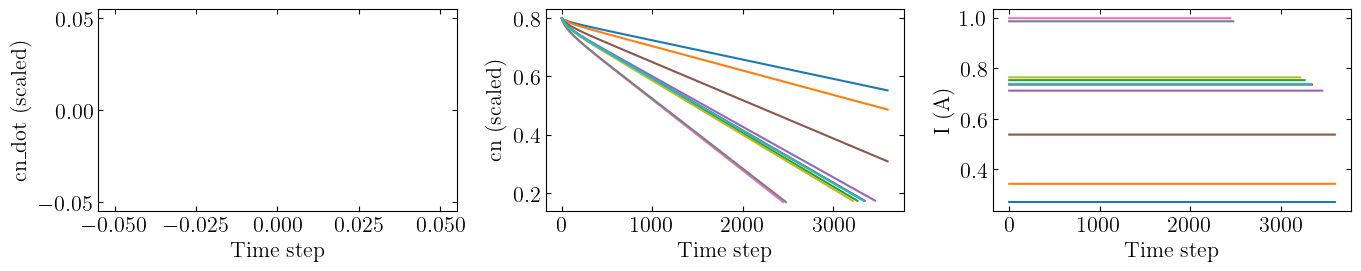

In [250]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 3))

for idb in range(min(10, cn_train_s.shape[0])):
    ax1.plot(cn_dot_train_s[idb, :, 0])
    ax2.plot(cn_train_s[idb, :, 0])
    ax3.plot(I_train[idb, :, 0])

ax1.set_ylabel("cn_dot (scaled)")
ax2.set_ylabel("cn (scaled)")
ax3.set_ylabel("I (A)")
for ax in (ax1, ax2, ax3):
    ax.set_xlabel("Time step")
plt.tight_layout()

In [241]:
# -----------------------------
# 2) Network
# -----------------------------
class Net(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features=2, out_features=hidden_dim), # input i_t, c_t
            nn.Tanh(),
            nn.Linear(hidden_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1),  # output c_dot_k
        )

    def forward(self, I, c):
        # x: [B*T, 1], c: [B*T, 1]
        x = torch.cat([I, c], dim=-1)  # [B*T, 2]
        output = self.net(x)
        return output
    
model = Net()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
mse = nn.MSELoss()

In [ ]:
# -----------------------------
# 3) Training loop
# -----------------------------


''' Mark 2: Unrolled training '''
# def training(epochs=50):
#     history = {"loss": []}
#     for ep in range(epochs):
#         model.train()
#         last = None

#         for I_batch, cn_batch, cn_dot_batch in loader:

#             optimizer.zero_grad()

#             loss = 0
#             dt=1

#             K = 40  # Time steps to unroll
#             s = torch.randint(0, T-K-1, (1,)).item()    # Random start index for unrolling
#             c_pred = cn_batch[:, s, :]

#             for k in range(K):

#                 I_k = I_batch[:, s+k, :]          # shape (B,1)

#                 c_dot_hat = model(I_k, c_pred)

#                 c_pred = c_pred + dt * c_dot_hat    # Euler forward

#                 c_true = cn_batch[:, s+k+1, :]  # shape (B,1)

#                 loss += mse(c_pred, c_true)

#             loss.backward()
#             optimizer.step()
#             last = loss.item()

#         history["loss"].append(last)

#         print(f'Epoch {ep+1} | loss {last} |')

#     return history

' Mark 2: Unrolled training '

In [243]:
def training(epochs=30):
    history = {"loss": []}
    for ep in range(epochs):
        model.train()
        last = None

        for I_batch, cn_batch, cn_dot_batch in loader:
            I_flat = I_batch.reshape(-1, 1)
            cn_flat = cn_batch.reshape(-1, 1)
            y_flat = cn_dot_batch.reshape(-1, 1)

            pred = model(I_flat, cn_flat)
            loss = mse(pred, y_flat)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            last = loss.item()

        history["loss"].append(last)
        print(f"Epoch {ep+1:02d} | loss {last:.3e}")

    return history

history = training(epochs=30)

Epoch 01 | loss nan
Epoch 02 | loss nan
Epoch 03 | loss nan
Epoch 04 | loss nan
Epoch 05 | loss nan
Epoch 06 | loss nan
Epoch 07 | loss nan
Epoch 08 | loss nan
Epoch 09 | loss nan
Epoch 10 | loss nan
Epoch 11 | loss nan
Epoch 12 | loss nan
Epoch 13 | loss nan
Epoch 14 | loss nan
Epoch 15 | loss nan
Epoch 16 | loss nan
Epoch 17 | loss nan
Epoch 18 | loss nan
Epoch 19 | loss nan
Epoch 20 | loss nan
Epoch 21 | loss nan
Epoch 22 | loss nan
Epoch 23 | loss nan
Epoch 24 | loss nan
Epoch 25 | loss nan
Epoch 26 | loss nan
Epoch 27 | loss nan
Epoch 28 | loss nan
Epoch 29 | loss nan
Epoch 30 | loss nan


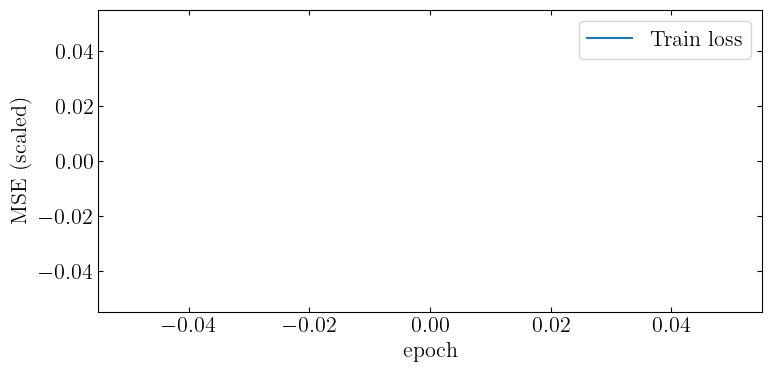

In [244]:
# -----------------------------
# 4) Test + plot
# -----------------------------

fig, (ax1) = plt.subplots(1, 1, figsize=(8, 4))

ax1.plot(history["loss"], label="Train loss")
ax1.set_xlabel("epoch")
ax1.set_ylabel("MSE (scaled)")
ax1.legend()

plt.tight_layout()

In [245]:
def rollout(idx=0):
    model.eval()
    cn_euler = np.zeros_like(cn_test_s)  # (B,T,1)

    cn_euler[idx, 0, 0] = cn_test_s[idx, 0, 0]

    cn_dot_hat_list = []
    dt = 1
    with torch.no_grad():
        for t in range(T-1):
            I_t = torch.tensor([[I_test[idx, t, 0]]], dtype=torch.float32)
            c_t = torch.tensor([[cn_euler[idx, t, 0]]], dtype=torch.float32)

            c_dot_hat = model(I_t, c_t).item()  # scaled 1/s
            cn_euler[idx, t+1, 0] = cn_euler[idx, t, 0] + dt * c_dot_hat
            cn_dot_hat_list.append(c_dot_hat)

    return cn_euler, np.array(cn_dot_hat_list)

idx = 0
cn_euler, cn_dot_hat_list = rollout(idx)

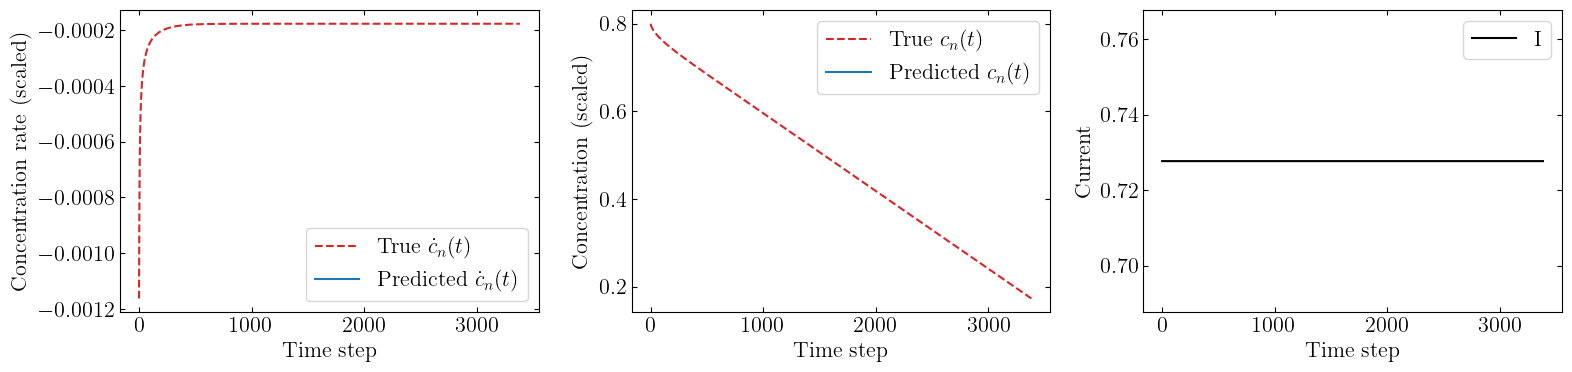

In [246]:
''' Plot '''
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))

ax1.plot(cn_dot_test_s[idx, :, 0],  color="tab:red", linestyle="dashed", label="True $\\dot{c}_n(t)$")
ax1.plot(cn_dot_hat_list, color="tab:blue", label="Predicted $\\dot{c}_n(t)$")
ax1.set_xlabel("Time step")
ax1.set_ylabel("Concentration rate (scaled)")
ax1.legend()

ax2.plot(cn_test_s[idx, :, 0], color="tab:red", linestyle="dashed", label="True $c_n(t)$")
ax2.plot(cn_euler[idx, :, 0], color="tab:blue", label="Predicted $c_n(t)$")
ax2.set_xlabel("Time step")
ax2.set_ylabel("Concentration (scaled)")
ax2.legend()

ax3.plot(I_test[idx, :, 0], label='I', color='black')
ax3.set_xlabel("Time step")
ax3.set_ylabel("Current")
ax3.legend()

plt.tight_layout()